<a href="https://colab.research.google.com/github/amanvashisth/Deep-Learning/blob/master/Improve%20Neural%20Network%20Performance/weight_initialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

# Generate dataset
X, y = make_classification(
    n_samples=1000,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

# Create DataFrame
df = pd.DataFrame(
    X,
    columns=["feature_1", "feature_2", "feature_3", "feature_4"]
)

df["target"] = y

# Display first 5 rows
df.head()

,feature_1,feature_2,feature_3,feature_4,target
0,-2.439926,-1.371106,-0.025787,-0.102379,0
1,-0.366951,1.380114,0.583490,0.443968,1
2,-1.321133,-0.680427,0.749495,-0.281137,1
3,-0.330055,1.443556,0.508346,1.019528,1
4,-1.211829,-2.021848,0.143790,0.501954,0


In [17]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [18]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

# Xavier Initialization

In [19]:
model = Sequential()

model.add(Dense(10,activation='tanh',input_dim=2))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.get_weights()

[array([[ 0.0414027 ,  0.6833132 ,  0.06322092, -0.25304294, -0.04504472,
         -0.52940637, -0.6110414 ,  0.54280335,  0.56584364,  0.24625796],
        [ 0.6512286 ,  0.3500108 ,  0.3731448 ,  0.08930039, -0.16842741,
          0.18189162, -0.12259442,  0.17995572,  0.47472757, -0.31181115]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.11583793, -0.34127915, -0.25512046,  0.51046264, -0.05489182,
          0.01251799,  0.36360753,  0.26503503,  0.49770916,  0.35698348],
        [-0.03551412,  0.03037041,  0.2701491 , -0.42888963,  0.4710232 ,
          0.4214648 , -0.0854986 , -0.52611756, -0.40007046, -0.22042158],
        [ 0.32644433,  0.31820965, -0.4128458 ,  0.3029347 ,  0.45569122,
         -0.34612018, -0.26504546, -0.1987859 ,  0.52526975, -0.07971436],
        [ 0.36541015,  0.2923364 , -0.41249466,  0.00940764,  0.39307636,
         -0.07061675,  0.02713931,  0.44036078,  0.5247388 ,  0.03571928],
        [ 0.43435

In [21]:
initial_weights = model.get_weights()

In [22]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [23]:
model.set_weights(initial_weights)

In [24]:
model.get_weights()

[array([[-0.32225204,  0.5595809 ,  0.12575802,  0.18113717, -0.14165097,
         -1.5518377 , -0.37013358, -1.333281  , -0.26396924,  0.30770746],
        [-1.4228295 ,  0.98174125, -1.3037381 ,  0.7033515 , -0.22865985,
          0.4825011 , -0.47911724, -0.6090025 , -0.24016269, -0.9156556 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-2.36039534e-01,  1.80379659e-01, -6.86537847e-03,
         -6.16254508e-01,  6.38839602e-02, -3.10010999e-01,
         -1.08498476e-01, -1.98880941e-01,  8.13142285e-02,
         -4.02002186e-01],
        [ 7.98159301e-01,  1.70438886e-01,  4.16924991e-03,
          4.53960538e-01, -4.32838619e-01,  1.44042835e-01,
         -7.97184169e-01,  1.97100312e-01, -2.59349257e-01,
         -1.39116913e-01],
        [ 4.79402654e-02, -3.26601118e-01, -7.41573572e-01,
         -1.00741774e-01,  2.46921301e-01, -7.70396292e-02,
         -4.10379827e-01,  4.46442723e-01,  1.54890805e-01,
         -8.0539393

In [25]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [26]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7025 - loss: 0.5967 - val_accuracy: 0.6950 - val_loss: 0.5992
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7063 - loss: 0.5833 - val_accuracy: 0.6950 - val_loss: 0.5891
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7075 - loss: 0.5806 - val_accuracy: 0.6950 - val_loss: 0.5835
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7075 - loss: 0.5773 - val_accuracy: 0.6950 - val_loss: 0.5789
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7063 - loss: 0.5749 - val_accuracy: 0.6900 - val_loss: 0.5784
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7063 - loss: 0.5735 - val_accuracy: 0.6950 - val_loss: 0.5758
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7088 - loss: 0.5726 - val_accuracy: 0.7000 - val_loss: 0.5755
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7088 - loss: 0.5703 - val_accuracy: 0.6950 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


<Axes: >

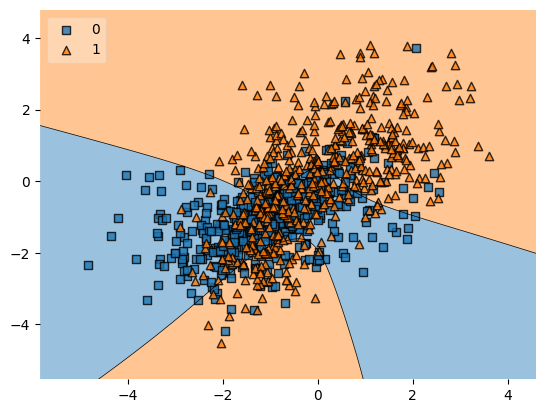

In [27]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

# He Initialization

In [28]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.get_weights()

[array([[-1.6424446 , -0.78373533, -0.44222862, -1.3809514 , -0.25414893,
          0.2123998 ,  0.50558764, -0.9942953 ,  1.6370742 ,  0.68206954],
        [ 1.2360603 ,  0.5194978 ,  0.6262751 , -0.16361912, -0.627335  ,
          0.6806247 , -0.5228563 , -1.6146466 ,  1.5394561 ,  1.1204321 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.00290017, -0.01974008,  0.95849764,  0.4258869 , -0.7870195 ,
          0.18421724,  0.7386036 ,  0.51939833,  0.5698125 ,  0.0046829 ],
        [-0.6523463 , -0.38021925,  0.3689223 , -0.01248372, -0.38782936,
          0.56301373,  0.00949832, -0.23680496,  0.29895   ,  0.02813099],
        [-0.90769553, -0.6200968 ,  0.04739958,  0.15084173,  0.6508702 ,
         -0.23322992, -0.1335463 ,  0.3487291 ,  0.88116485,  0.06666517],
        [ 0.75151324, -0.74448425, -0.20274217,  0.543435  , -0.16847275,
         -0.14051573, -0.45731091,  0.5816067 , -0.7644677 ,  0.4117135 ],
        [-0.05840

In [30]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [31]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3900 - loss: 0.7787 - val_accuracy: 0.6600 - val_loss: 0.6497
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6612 - loss: 0.6079 - val_accuracy: 0.6650 - val_loss: 0.5930
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6687 - loss: 0.5739 - val_accuracy: 0.6700 - val_loss: 0.5801
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6750 - loss: 0.5644 - val_accuracy: 0.6550 - val_loss: 0.5750
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6888 - loss: 0.5602 - val_accuracy: 0.6750 - val_loss: 0.5725
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6975 - loss: 0.5571 - val_accuracy: 0.6750 - val_loss: 0.5695
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6975 - loss: 0.5554 - val_accuracy: 0.6700 - val_loss: 0.5688
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7063 - loss: 0.5527 - val_accuracy: 0.6600 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

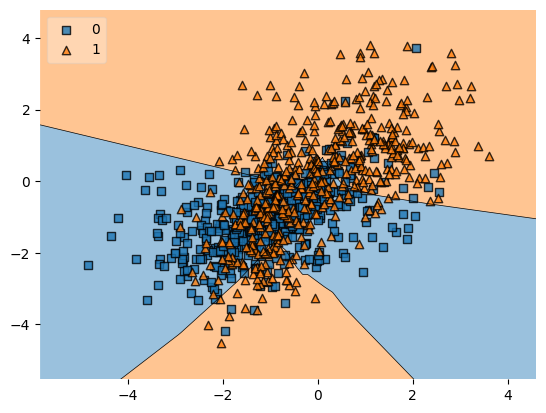

In [32]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)